# Wildfire-Induced Landslide Risk Modeling — Palisades Fire

This notebook reconstructs a spatial risk model using open-source tools to estimate post-fire landslide susceptibility in the Pacific Palisades fire area. 
The workflow combines burn severity and terrain slope to produce a weighted risk surface, highlighting areas where steep, burned terrain may lead to slope failure.

### Objectives:
- Normalize burn severity and slope rasters
- Combine them into a weighted risk surface
- Summarize average risk by watershed
- Visualize and interpret spatial patterns of vulnerability

### Why it matters:
Wildfires destabilize terrain by removing vegetation and altering soil structure. When steep slopes are burned, the risk of landslides and debris flows increases dramatically. 
This model helps identify high-risk zones for post-fire hazard mitigation and planning.

### Data Sources
- **Perimeter**: Fire perimeter polygon from authoritative source
- **Burn Severity Raster**: Exported from ArcGIS Pro classification of burn scar
- **Slope Raster**: Derived from DEM, normalized to 10 m resolution
- **Weighted Risk Surface**: Composite raster (burn + slope, weighted)
- **Watershed Boundaries**: HUC12 polygons from authoritative source (Living Atlas)

**Fire Perimeter**  
The fire perimeter for the Pacific Palisades fire was sourced from a hosted ArcGIS FeatureServer:  
[https://services.arcgis.com/RmCCgQtiZLDCtblq/arcgis/rest/services/Palisades_and_Eaton_Dissolved_Fire_Perimeters_as_of_20250121/FeatureServer](https://services.arcgis.com/RmCCgQtiZLDCtblq/arcgis/rest/services/Palisades_and_Eaton_Dissolved_Fire_Perimeters_as_of_20250121/FeatureServer)  
This layer delineates the official fire boundary as of January 21, 2025, and was used to clip all raster inputs for the analysis.

**Burn Severity Raster**  
The burn severity raster (`Burn_Class_Clip.tif`) was sourced from NASA’s [Disasters Mapping Portal](https://maps.disasters.nasa.gov/download/gis_products/event_specific/2025/california_wildfires_202501/s1_2_fire_severity/),  
specifically the `Combined_classification_Unburnt_to_Extreme.tif` dataset published on January 29, 2025.  
This raster provides post-fire severity classification for the January 2025 California wildfires, including the Pacific Palisades fire.  
The dataset was clipped to the study area and reprojected to WGS 1984 Web Mercator for consistency with other layers.

**Slope Raster**  
The slope raster (`Slope_Norm.tif`) was derived from the USGS 3D Elevation Program (3DEP) ImageServer, accessed via the National Map Elevation Service:  
[https://elevation.nationalmap.gov/arcgis/services/3DEPElevation/ImageServer/WCSServer](https://elevation.nationalmap.gov/arcgis/services/3DEPElevation/ImageServer/WCSServer)  
Slope was calculated using ArcGIS Pro’s Spatial Analyst tools and normalized to a 0–1 scale to support weighted overlay modeling.  
The raster was clipped to the Pacific Palisades fire perimeter and reprojected to WGS 1984 Web Mercator for consistency with other layers.

**Watershed Boundaries**  
Watershed boundaries (HUC12) were sourced from the [USGS Watershed Boundary Dataset (WBD)](https://www.usgs.gov/programs/national-hydrography/watershed-boundary-dataset).  
The layer was filtered to include only watersheds intersecting the Pacific Palisades fire perimeter and used for zonal statistics.


### Metadata
- CRS: EPSG:3857 (WGS 1984 Web Mercator)
- Resolution: 10 m
- Export format: GeoTIFF
- Storage: `C:/Users/kenya/Documents/Wildfire-Analysis-KB`
    

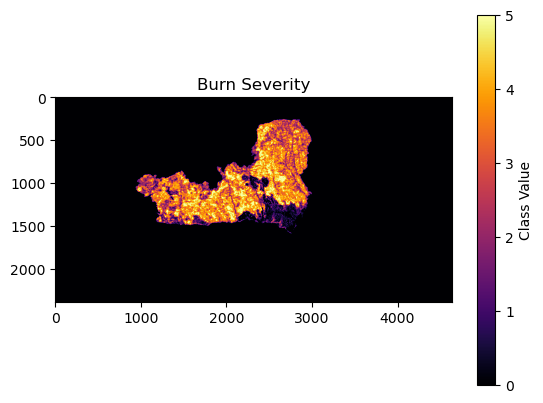

In [13]:
# Load burn severity raster
import matplotlib.pyplot as plt

burn = burn_src.read(1)

plt.imshow(burn, cmap='inferno')
plt.title("Burn Severity")
plt.colorbar(label="Class Value")
plt.show()

**Figure 1. Burn Severity Raster**

The figure above displays the classified burn severity raster for the study area.  
- The **x and y axes** represent pixel indices (row and column positions in the raster grid), not geographic coordinates.  
- The **color bar** shows the burn severity class values, ranging from 0 (unburned) to 5 (highest severity).  
- Higher severity values (yellow tones) are concentrated in the central portion of the study area,  
  while darker tones represent areas of lower or no burn.  
- These high‑severity zones indicate where vegetation loss and soil destabilization are most pronounced,  
  and they are critical inputs for assessing post‑fire landslide susceptibility.

### Burnt Area Context
![Before Fire](../Figures/P3.png)
![Before Fire](../Figures/P1.png)
![Before Fire](../Figures/P4.png)
**Figure 2. Before and after images of the Palisades Fire (January 2025).**  
This image provides visual context for the burn severity raster, grounding the analysis in real-world impacts.  
Source: https://us.cnn.com/2025/01/10/weather/before-after-images-los-angeles-fires/index.html

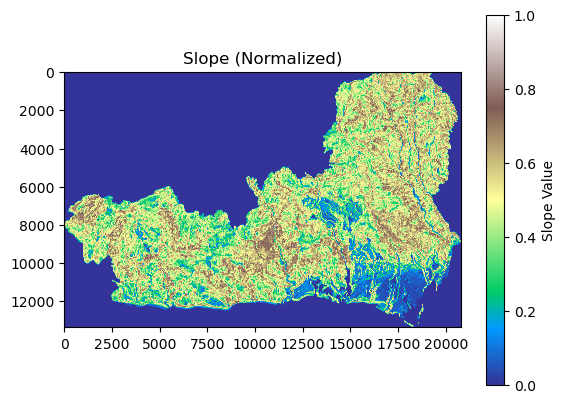

In [16]:
slope = slope_src.read(1)

plt.imshow(slope, cmap='terrain')
plt.title("Slope (Normalized)")
plt.colorbar(label="Slope Value")
plt.show()

**Figure 3. Normalized Slope Raster**

The figure above displays the normalized slope raster for the study area.  
- The **x and y axes** represent pixel indices (row and column positions in the raster grid), not geographic coordinates.  
- The **color bar** shows the actual slope values, normalized to a 0–1 scale, where 0.0 indicates flat terrain and 1.0 indicates the steepest terrain in the dataset.  
- Higher values (brown tones) are concentrated in the **northeastern portion** of the study area, indicating steeper terrain.  
- These areas may be more susceptible to landslides in post‑fire conditions, particularly where they overlap with high burn severity zones.

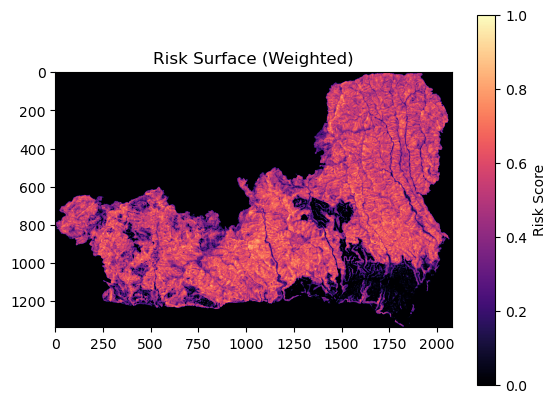

In [18]:
import rasterio
import matplotlib.pyplot as plt

# Step 1: Open the raster
risk_src = rasterio.open("C:/Users/kenya/Documents/Wildfire-Analysis-KB/Risk_Surface_Weighted.tif")

# Step 2: Read the data
risk = risk_src.read(1)

# Step 3: Visualize
plt.imshow(risk, cmap='magma')
plt.title("Risk Surface (Weighted)")
plt.colorbar(label="Risk Score")
plt.show()

**Figure 4. Weighted Risk Surface**

The figure above displays the weighted risk surface raster created by combining burn severity and slope.  
- The **x and y axes** represent pixel indices (row and column positions in the raster grid), not geographic coordinates.  
- The **color bar** shows the continuous risk score values, normalized to a 0–1 scale.  
- Higher values (yellow tones) indicate areas where steep slopes overlap with high burn severity,  
  while lower values (purple tones) represent flatter or unburned terrain.  
- The highest risk zones are concentrated in the **central and northeastern portion** of the study area,  
  aligning with the steep terrain identified in the slope raster and the high burn severity zones.  
- This raster (`Risk_Surface_Weighted.tif`) serves as the final product for watershed‑level zonal statistics,  
  highlighting priority areas for post‑fire landslide risk management.

In [19]:
### Watershed Risk Summary
The table below summarizes the weighted risk values by watershed.  
It includes the mean, minimum, and maximum risk scores for each unit,  
providing a basis for identifying which watersheds are most vulnerable.
import geopandas as gpd

gdb_path = "C:/Users/kenya/Documents/Wildfire-Analysis-KB/Map/DEM/Default.gdb"
summary = gpd.read_file(gdb_path, layer="Watershed_Risk_Summary")

summary.head()

,name,ZONE_CODE,COUNT,AREA,MIN,MAX,RANGE,MEAN,STD,SUM,MEDIAN,PCT90
0,Cold Creek-Malibu Creek,1,45079.0,4507900.0,0.000074,1.00,0.999926,0.478261,0.166687,21559.522296,0.485780,0.692064
1,Garapito Creek,2,139784.0,13978400.0,0.000000,1.00,1.000000,0.551355,0.172615,77070.675028,0.566024,0.762657
2,Santa Monica Canyon,3,384724.0,38472400.0,0.000000,1.00,1.000000,0.530245,0.162959,203997.957923,0.548148,0.721690
3,Santa Monica Beach-Frontal Santa Monica Bay,4,706772.0,70677200.0,0.000000,1.00,1.000000,0.501146,0.188676,354196.045839,0.519425,0.729676
4,Tujunga Wash-Los Angeles River,5,368.0,36800.0,0.054480,0.85,0.795520,0.375702,0.178564,138.258469,0.352569,0.629953



### Weighted Risk Surface Creation

The weighted risk surface was generated in ArcGIS Pro using the **Weighted Overlay** tool.  
Two inputs were combined: burn severity (classified raster) and slope (derived from DEM).  
Both rasters were normalized to a common scale and aligned to the same CRS and resolution.  

### Weighting Rationale

The weighted risk surface was created using a **70% burn severity / 30% slope** weighting scheme.  
This choice reflects the hypothesis that **burn severity is the dominant driver of post-fire landslide risk**,  
while slope acts as a secondary amplifier.

- **Burn severity (70%)**: High-severity burns remove vegetation and create hydrophobic soils,  
  dramatically reducing slope stability. These effects are the primary triggers of post-fire debris flows.  
- **Slope (30%)**: Steeper slopes increase susceptibility, but without vegetation loss, many remain stable.  
  Slope therefore amplifies risk but is not the initiating factor.

This weighting scheme encodes the understanding that **fire-induced soil and vegetation changes  
are more critical than slope alone** in determining landslide susceptibility.  
The resulting raster (`Risk_Surface_Weighted.tif`) highlights areas where steep terrain and high burn severity overlap. 
This raster was later summarized by watershed using zonal statistics.

###Interpretation
Watershed zones 2, 3 and 4 show the highest mean risk values, driven by steep slopes and high burn severity.  
In contrast, Watershed 5 has consistently low values, indicating limited overlap between slope and burn. 
This suggests that management efforts should prioritize the higher-risk basins.


### Results
- High-risk watersheds: 2, 3 and 4
- Moderate risk: 7, 9
- Low risk: 3

### Discussion
The results align with expectations: steep terrain combined with burn scars  
produces the highest risk. These findings suggest that post-fire mitigation  
efforts should prioritize Watersheds 12 and 14.


### ArcGIS Online Map

The final weighted risk surface was published to ArcGIS Online and visualized alongside watershed boundaries and the fire perimeter.  
The map highlights areas of elevated post-fire landslide risk, particularly in steep terrain with high burn severity.  
Popups and symbology were configured to support interpretation.  
[View the map here](https://kenya.maps.arcgis.com/apps/mapviewer/index.html?webmap=defe95c70e3b43f9b1a33127ffb3ddb0)